In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns

In [14]:
df = pd.read_pickle("cleaned_chicago_crime_data.pkl")

In [3]:
df.head()

,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,...,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Location,ID,District,Community Area,Updated On
0,JK184891,2026-03-18,069XX S CORNELL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,332,...,1188552.0,1859230.0,2026,41.768797,-87.584413,POINT (-87.584412909 41.768797328),14139805,3,43,2026-03-25 15:57:05
1,JK184982,2026-03-18,082XX S CORNELL AVE,0820,THEFT,$500 AND UNDER,VEHICLE NON-COMMERCIAL,False,False,411,...,1188698.0,1850652.0,2026,41.745255,-87.584152,POINT (-87.584151569 41.745255037),14139911,4,45,2026-03-25 15:57:05
2,JK188256,2026-03-18,034XX N RIDGEWAY AVE,0810,THEFT,OVER $500,RESIDENCE,False,False,1732,...,1150784.0,1922573.0,2026,41.943437,-87.721197,POINT (-87.721197255 41.943437198),14142669,17,21,2026-03-25 15:57:05
4,JK186910,2026-03-18,072XX S DAMEN AVE,1130,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,RESIDENCE,False,False,735,...,1164278.0,1856611.0,2026,41.762156,-87.673463,POINT (-87.673462943 41.762155987),14141280,7,67,2026-03-25 15:57:05
5,JK185040,2026-03-18,032XX N RICHMOND ST,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,False,False,1733,...,1156145.0,1921418.0,2026,41.940161,-87.701524,POINT (-87.701524029 41.940161052),14139899,17,21,2026-03-25 15:57:05


In [4]:
df.dtypes

Case Number                     object
Date                    datetime64[ns]
Block                         category
IUCR                          category
Primary Type                  category
Description                   category
Location Description          category
Arrest                            bool
Domestic                          bool
Beat                             int64
Ward                             Int64
FBI Code                      category
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Latitude                       float64
Longitude                      float64
Location                        object
ID                               Int64
District                         Int64
Community Area                   Int64
Updated On              datetime64[ns]
dtype: object

In [5]:
# CRIME DISTRIBUTION
crime_counts = df["Primary Type"].value_counts()
crime_counts.head(10)

Primary Type
THEFT                  116036
BATTERY                 89636
CRIMINAL DAMAGE         55004
ASSAULT                 45287
MOTOR VEHICLE THEFT     38758
OTHER OFFENSE           33854
DECEPTIVE PRACTICE      28444
BURGLARY                19054
ROBBERY                 14422
NARCOTICS               13707
Name: count, dtype: int64

<Axes: xlabel='Primary Type'>

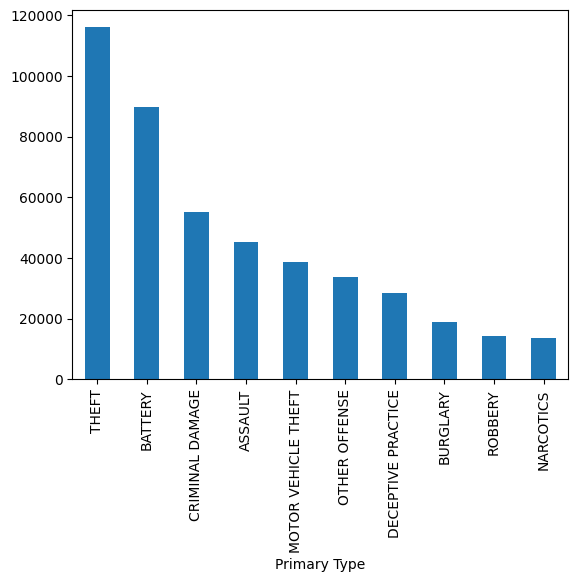

In [6]:
crime_counts.head(10).plot(kind="bar")

<Axes: xlabel='Longitude', ylabel='Latitude'>

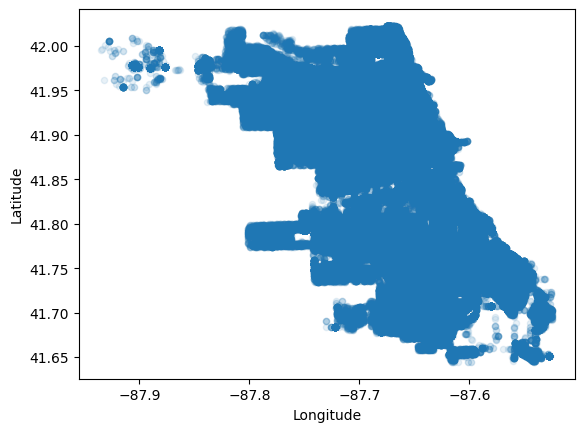

In [7]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.1)

<Axes: xlabel='Longitude', ylabel='Latitude'>

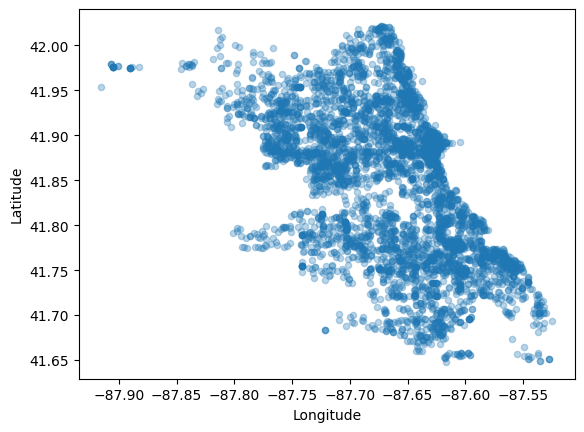

In [ ]:
# recent five thousand crime locations 
df.head(5000).plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.3)

<Axes: xlabel='Hour'>

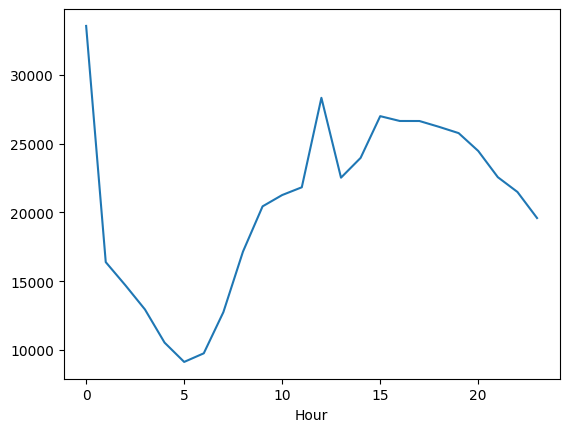

In [15]:
# temporal trends
df["Hour"] = df["Date"].dt.hour
df["Hour"].value_counts().sort_index().plot(kind="line")

<Axes: xlabel='Day'>

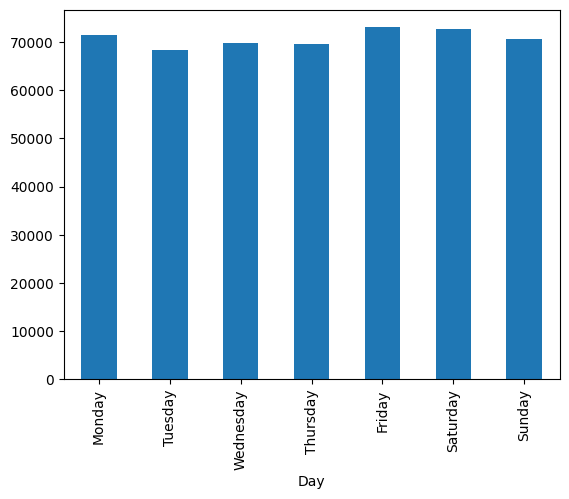

In [4]:
df["Day"] = df["Date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day"].value_counts().reindex(order).plot(kind="bar")

<Axes: xlabel='Month'>

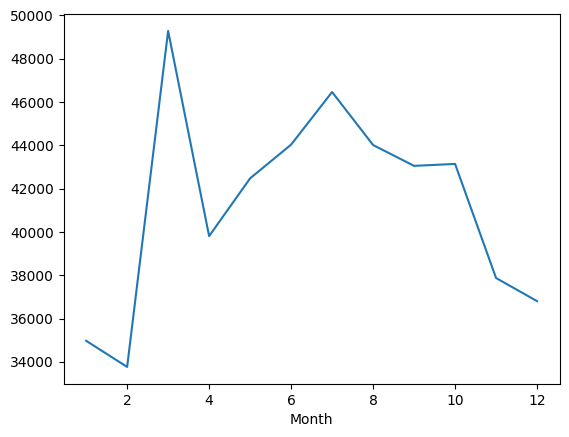

In [17]:
df["Month"] = df["Date"].dt.month
df["Month"].value_counts().sort_index().plot(kind="line")

In [19]:
df["Arrest"].value_counts(normalize=False)

Arrest
False    421247
True      74461
Name: count, dtype: int64

In [20]:
pd.crosstab(df["Primary Type"], df["Arrest"])

Arrest,False,True
Primary Type,,
ARSON,770,71
ASSAULT,39981,5306
BATTERY,73335,16301
BURGLARY,18124,930
CONCEALED CARRY LICENSE VIOLATION,9,473
CRIMINAL DAMAGE,52719,2285
CRIMINAL SEXUAL ASSAULT,3207,106
CRIMINAL TRESPASS,7356,3247
DECEPTIVE PRACTICE,27504,940


In [22]:
df["Domestic"].value_counts(normalize=False)

Domestic
False    402240
True      93468
Name: count, dtype: int64

In [23]:
pd.crosstab(df["Primary Type"], df["Domestic"])

Domestic,False,True
Primary Type,,
ARSON,764,77
ASSAULT,32401,12886
BATTERY,42110,47526
BURGLARY,18427,627
CONCEALED CARRY LICENSE VIOLATION,481,1
CRIMINAL DAMAGE,47505,7499
CRIMINAL SEXUAL ASSAULT,2665,648
CRIMINAL TRESPASS,9797,806
DECEPTIVE PRACTICE,27969,475


In [24]:
df.describe()

,Date,Beat,Ward,X Coordinate,Y Coordinate,Year,Latitude,Longitude,ID,District,Community Area,Updated On,Hour,Month
count,495708,495708.000000,495708.0,4.957080e+05,4.957080e+05,495708.000000,495708.000000,495708.000000,495708.0,495708.0,495708.0,495708,495708.000000,495708.000000
mean,2025-02-22 19:03:42.182091776,1148.653784,23.095683,1.165518e+06,1.887352e+06,2024.644228,41.846472,-87.668086,13733049.511152,11.256415,36.308113,2025-10-14 12:00:53.943627520,12.498312,6.537690
min,2024-02-28 06:00:00,111.000000,1.0,1.092647e+06,1.813897e+06,2024.000000,41.644590,-87.934567,28000.0,1.0,1.0,2024-03-07 15:41:23,0.000000,1.000000
25%,2024-08-17 20:00:00,532.000000,10.0,1.154228e+06,1.860321e+06,2024.000000,41.772218,-87.709226,13570619.5,5.0,22.0,2025-05-17 15:40:52,8.000000,4.000000
50%,2025-02-20 00:32:30,1033.000000,23.0,1.167440e+06,1.893841e+06,2025.000000,41.864312,-87.660715,13757415.5,10.0,32.0,2025-11-02 15:41:09,13.000000,7.000000
75%,2025-08-23 23:55:30,1731.000000,34.0,1.176795e+06,1.910160e+06,2025.000000,41.909350,-87.626819,13948292.5,17.0,53.0,2026-03-14 15:41:39,18.000000,9.000000
max,2026-03-18 00:00:00,2535.000000,50.0,1.205119e+06,1.951517e+06,2026.000000,42.022559,-87.524529,14145546.0,31.0,77.0,2026-03-25 15:57:05,23.000000,12.000000
std,NaN,708.237045,13.930386,1.620395e+04,3.142993e+04,0.631984,0.086428,0.059004,648474.879768,7.077098,21.550616,NaN,6.832808,3.327575


In [25]:
df.describe(include='category')

,Block,IUCR,Primary Type,Description,Location Description,FBI Code
count,495708,495708,495708,495708,495708,495708
unique,32151,353,31,331,133,26
top,001XX N STATE ST,0486,THEFT,SIMPLE,STREET,06
freq,1215,39518,116036,62246,132530,121389


In [26]:
df.nunique()

Date                    253799
IUCR                       353
Primary Type                31
Description                331
Location Description       133
Arrest                       2
Domestic                     2
Beat                       275
Ward                        50
FBI Code                    26
Year                         3
Latitude                189134
Longitude               189113
District                    23
Community Area              77
Month                       12
Day                          7
Hour                        24
dtype: int64

In [5]:
df[["Latitude", "Longitude", "X Coordinate", "Y Coordinate"]].corr()

,Latitude,Longitude,X Coordinate,Y Coordinate
Latitude,1.000000,-0.517778,-0.528906,0.999995
Longitude,-0.517778,1.000000,0.999914,-0.514949
X Coordinate,-0.528906,0.999914,1.000000,-0.526099
Y Coordinate,0.999995,-0.514949,-0.526099,1.000000
